In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [4]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([1, 0, 0, 1])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
best_mlp = None
best_accuracy = 0.0

In [11]:
hidden_layer_sizes_to_try = [(1,), (2,), (3,), (4,)]
for hidden_layer_size in hidden_layer_sizes_to_try:
    for random_state in range(1000):
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden_layer_size,
            activation='logistic',
            solver='lbfgs',
            max_iter=1000,
            random_state=random_state
        )

        mlp.fit(X_train, y_train)
        accuracy = mlp.score(X_train, y_train)

        if accuracy == 1.0:
            print(f"100% acuracia  {hidden_layer_size} and random state {random_state}")
            best_mlp = mlp
            best_accuracy = 1.0
            break

    if best_accuracy == 1.0:
        break
if best_mlp is not None:
    print("\nMelhor classificador MLP encontrado:")
    print(best_mlp)
    print(f"Acuracia no teste: {best_mlp.score(X_test, y_test)}")
else:
    print("\nNão alcançou")


100% acuracia  (1,) and random state 0

Melhor classificador MLP encontrado:
MLPClassifier(activation='logistic', hidden_layer_sizes=(1,), max_iter=1000,
              random_state=0, solver='lbfgs')
Acuracia no teste: 0.0


# Letra B e C

Um único perceptron não é suficiente para separar os dados XNOR porque os dados não são linearmente separáveis. O menor número de neurônios para separar dados XNOR 2.


In [17]:
X_xnor =  np.array([[0,0],[0,1],[1,0],[1,1]])
Y_xnor = np.array([1, 0, 0, 1])
mlp = MLPClassifier(activation='logistic', solver='lbfgs')
param_grid = {
    'hidden_layer_sizes': [(i,) for i in range(1, 16)],
    'random_state': range(21)
}

grid_search = GridSearchCV(mlp, param_grid, cv=2, scoring='accuracy')

grid_search.fit(X_xnor, Y_xnor)


print("Melhores parâmetros:", grid_search.best_params_)


print("Melhor acurácia:", grid_search.best_score_)

Melhores parâmetros: {'hidden_layer_sizes': (1,), 'random_state': 0}
Melhor acurácia: 0.0


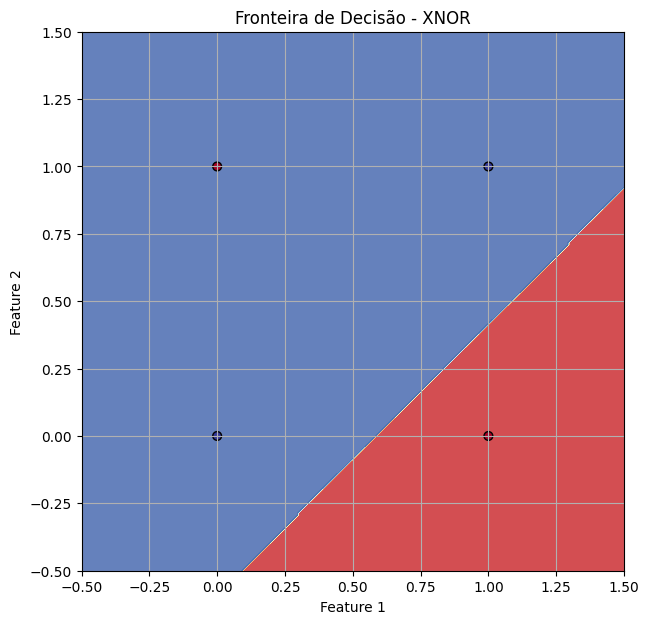

In [33]:
x_min, x_max = X_xnor[:, 0].min() - 0.5, X_xnor[:, 0].max() + 0.5
y_min, y_max = X_xnor[:, 1].min() - 0.5, X_xnor[:, 1].max() + 0.5

# Gerar uma grade de pontos
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Empilhar os pontos para previsão
grid = np.c_[xx.ravel(), yy.ravel()]

Z = best_mlp.predict(grid)
Z = Z.reshape(xx.shape)

# Plotar a fronteira
plt.figure(figsize=(7, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

# Plotar os pontos reais
plt.scatter(X_xnor[:, 0], X_xnor[:, 1], c=Y_xnor, edgecolor="k", s=40, cmap=plt.cm.RdYlBu)

plt.title('Fronteira de Decisão - XNOR')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(True)
plt.show()


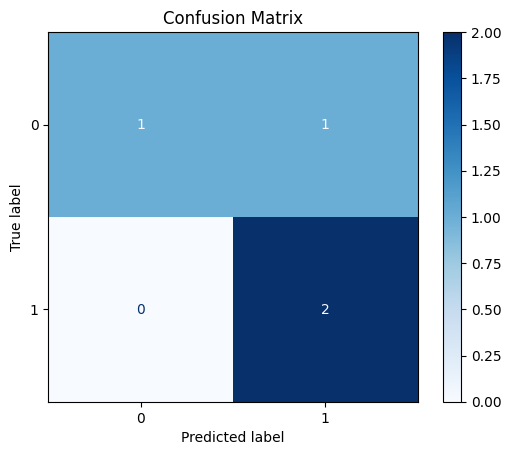

In [25]:

y_pred = best_mlp.predict(X_xnor)

cm = confusion_matrix(Y_xnor, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(Y_xnor))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


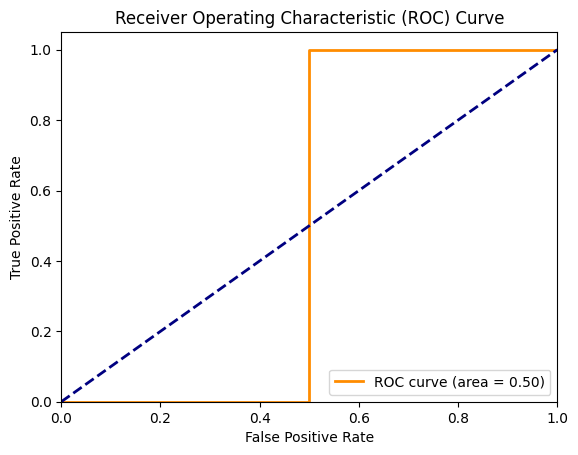

In [28]:
y_prob = best_mlp.predict_proba(X_xnor)[:, 1]

fpr, tpr, thresholds = roc_curve(Y_xnor, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [29]:
print(f"Área SOBRE A CURAVA: {roc_auc:.2f}")

Área SOBRE A CURAVA: 0.50
